In [30]:
#cau1
import pandas as pd 
import seaborn as sns

def load_data():
    """
    Load Titanic dataset from seaborn
    Returns:
        DataFrame: Titanic dataset
    """
    df = sns.load_dataset("titanic")
    return df

df = load_data()
df.head(10)



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


            Total Missing  Percentage (%)
nameprefix             24        2.693603
embarked                2        0.224467


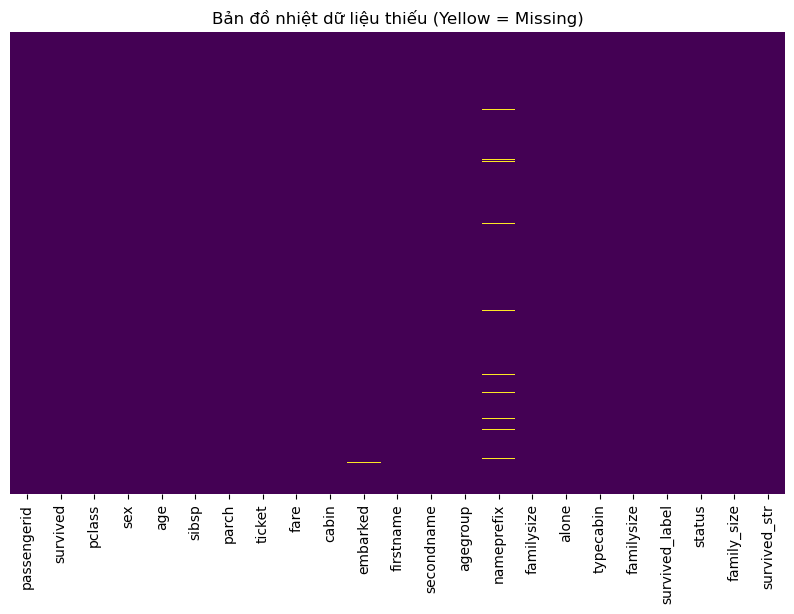

In [65]:
#cau 2
import matplotlib.pyplot as plt 

# Thống kê số lượng và tỉ lệ % thiếu hụt
missing_data = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Tạo bảng tổng hợp
missing_report = pd.DataFrame({'Total Missing': missing_data, 'Percentage (%)': missing_percentage})
print(missing_report[missing_report['Total Missing'] > 0].sort_values(by='Total Missing', ascending=False))

# Trực quan hóa Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Bản đồ nhiệt dữ liệu thiếu (Yellow = Missing)")
plt.show()


In [32]:
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [33]:
#cau 3
df = pd.read_csv("D:/thinh/DuLieu/titanic_disaster.csv")
df.columns

df[['firstName', 'secondName']] = df['Name'].str.split(',', expand=True)

df['firstName'] = df['firstName'].str.strip()
df['secondName'] = df['secondName'].str.strip()

df.drop(columns=['Name'], inplace=True)

df[['firstName', 'secondName']].head()



,firstName,secondName
0,Braund,Mr. Owen Harris
1,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss. Laina
3,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,Allen,Mr. William Henry


In [34]:
#cau4
df['Sex'].value_counts()
df['Sex'] = df['Sex'].map({'male': 'M', 'female': 'F'})
df['Sex'].value_counts()


Sex
M    577
F    314
Name: count, dtype: int64

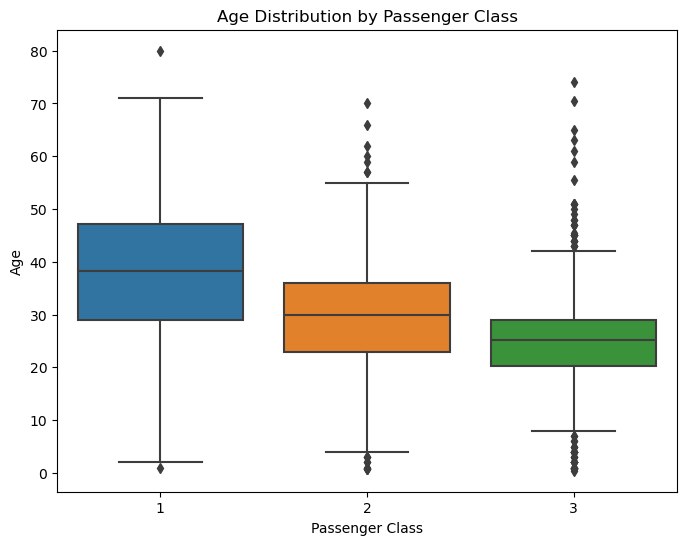

In [63]:
#cau 5a
plt.figure(figsize=(8,6))
sns.boxplot(x='pclass', y='age', data=df)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()


In [64]:
#cau 5b
df['age'].isnull().sum()
df['age'] = df.groupby('pclass')['age'].transform(
    lambda x: x.fillna(x.mean())
)
df['age'].isnull().sum()
df[['pclass', 'age']].head(10)




,pclass,age
0,3,22.00000
1,1,38.00000
2,3,26.00000
3,1,35.00000
4,3,35.00000
5,3,25.14062
6,1,54.00000
7,3,2.00000
8,3,27.00000
9,2,14.00000


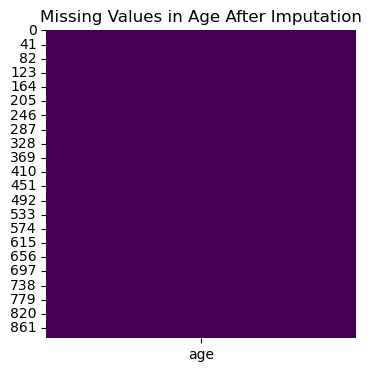

In [66]:
#cau 5b
plt.figure(figsize=(4,4))
sns.heatmap(df[['age']].isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values in Age After Imputation")
plt.show()

In [68]:
#cau 6
bins = [0, 12, 18, 60, 120]
labels = ['Kid', 'Teen', 'Adult', 'Older']

df['Agegroup'] = pd.cut(df['age'], bins=bins, labels=labels)
df[['age', 'Agegroup']].head(10)
df['Agegroup'].value_counts()


Agegroup
Adult    730
Teen      70
Kid       69
Older     22
Name: count, dtype: int64

In [72]:
#cau 7
df['namePrefix'] = df['secondname'].str.extract(
    r'(Mr|Mrs|Miss|Master)', expand=False
)
df[['secondname', 'namePrefix']].head(10)
df['namePrefix'].value_counts()


namePrefix
Mr        645
Miss      182
Master     40
Name: count, dtype: int64

In [40]:
#cau 8 
df['familySize'] = 1 + df['SibSp'] + df['Parch']
df[['SibSp', 'Parch', 'familySize']].head(10)
df['familySize'].value_counts().sort_index()


familySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [41]:
#cau 9
df['Alone'] = (df['familySize'] == 1).astype(int)
df[['familySize', 'Alone']].head(10)
df['Alone'].value_counts()


Alone
1    537
0    354
Name: count, dtype: int64

In [42]:
#cau 10
df['Cabin'].isnull().sum()
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['typeCabin'] = df['Cabin'].str[0]
df[['Cabin', 'typeCabin']].head(10)




,Cabin,typeCabin
0,Unknown,U
1,C85,C
2,Unknown,U
3,C123,C
4,Unknown,U
5,Unknown,U
6,E46,E
7,Unknown,U
8,Unknown,U
9,Unknown,U


In [43]:
df['typeCabin'].value_counts()

typeCabin
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

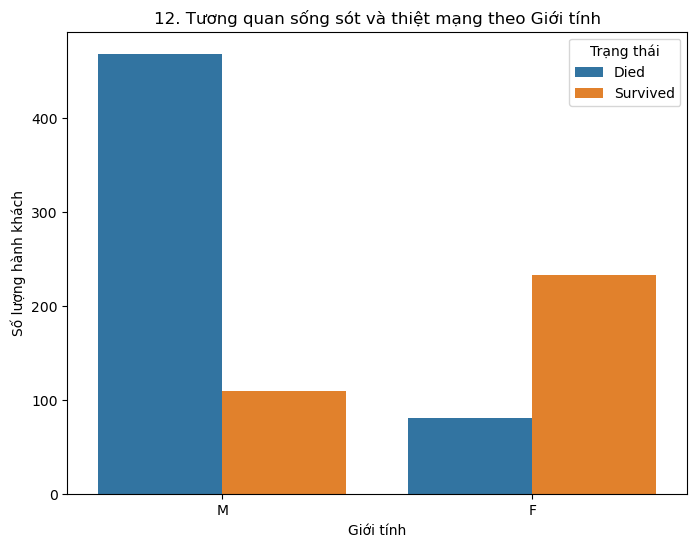

In [49]:
#cau 12
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuẩn hóa tên cột về chữ thường (để khớp với sibsp, parch, sex...)
df.columns = df.columns.str.lower()

# 2. Tính toán FamilySize (sử dụng tên cột chữ thường)
df['familysize'] = df['sibsp'] + df['parch'] + 1

# 3. Ánh xạ 0/1 thành văn bản để tránh lỗi 'startswith' và làm biểu đồ đẹp hơn
# Tạo một cột tạm thời cho việc hiển thị
df['survived_label'] = df['survived'].map({0: 'Died', 1: 'Survived'})

# 4. Vẽ biểu đồ (Yêu cầu 12)
plt.figure(figsize=(8, 6))
sns.countplot(x='sex', hue='survived_label', data=df)
plt.title('12. Tương quan sống sót và thiệt mạng theo Giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng hành khách')
plt.legend(title='Trạng thái')
plt.show()

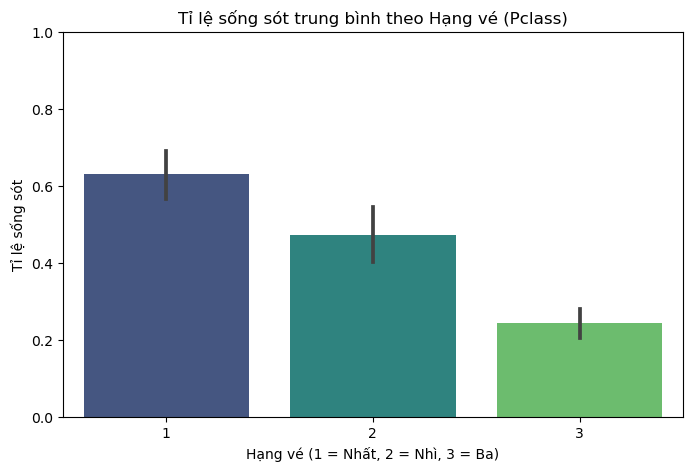

In [51]:
#cau 13


# Đảm bảo tên cột ở dạng chữ thường để khớp với dữ liệu thực tế
df.columns = df.columns.str.lower()

# Vẽ biểu đồ tỉ lệ sống sót theo Hạng vé (Pclass)
plt.figure(figsize=(8, 5))
sns.barplot(x='pclass', y='survived', data=df, palette='viridis')

# Thêm tiêu đề và nhãn
plt.title('Tỉ lệ sống sót trung bình theo Hạng vé (Pclass)')
plt.xlabel('Hạng vé (1 = Nhất, 2 = Nhì, 3 = Ba)')
plt.ylabel('Tỉ lệ sống sót')
plt.ylim(0, 1) # Tỉ lệ nằm trong khoảng từ 0 đến 1
plt.show()

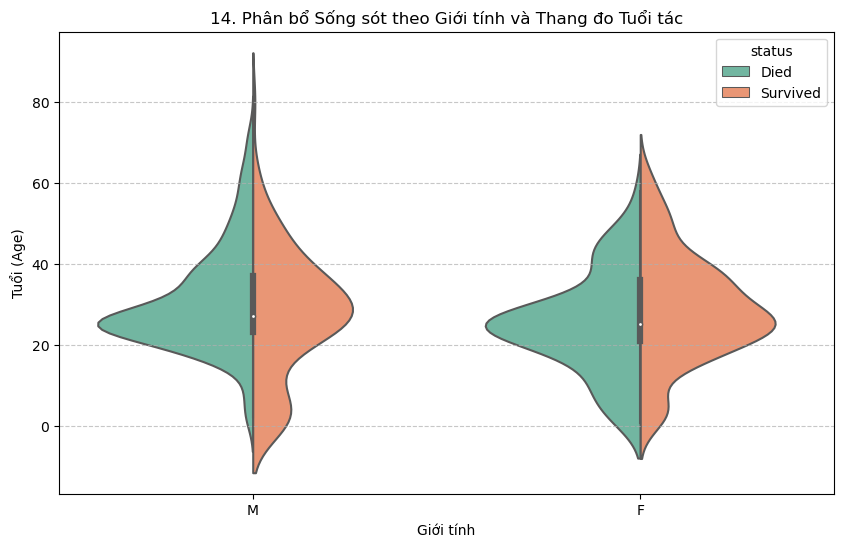

In [52]:
df.columns = df.columns.str.lower()

# Tạo nhãn để tránh lỗi 'startswith' và giúp biểu đồ dễ đọc
df['status'] = df['survived'].map({0: 'Died', 1: 'Survived'})

plt.figure(figsize=(10, 6))
# Sử dụng violinplot để xem phân phối tuổi tác
sns.violinplot(x='sex', y='age', hue='status', split=True, data=df, palette='Set2')

# Thêm thông tin bổ trợ
plt.title('14. Phân bổ Sống sót theo Giới tính và Thang đo Tuổi tác')
plt.xlabel('Giới tính')
plt.ylabel('Tuổi (Age)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

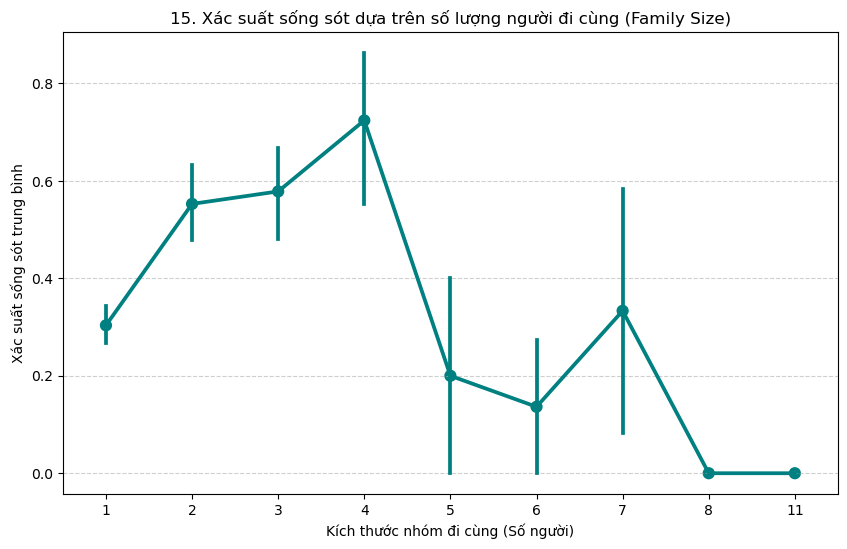

In [53]:
# 1. Feature Engineering: Tạo cột family_size
# Công thức: sibsp + parch + 1 (cộng thêm chính hành khách đó)
df['family_size'] = df['sibsp'] + df['parch'] + 1

# 2. Vẽ biểu đồ pointplot để thấy xu hướng xác suất sống sót
plt.figure(figsize=(10, 6))
sns.pointplot(x='family_size', y='survived', data=df, color='teal')

# 3. Thêm tiêu đề và nhãn
plt.title('15. Xác suất sống sót dựa trên số lượng người đi cùng (Family Size)')
plt.xlabel('Kích thước nhóm đi cùng (Số người)')
plt.ylabel('Xác suất sống sót trung bình')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

c:\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


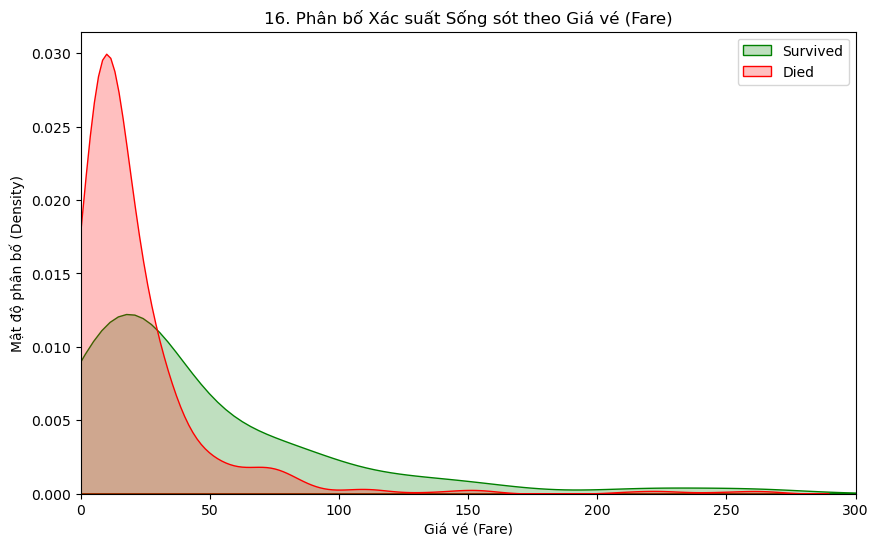

In [55]:
# Đảm bảo tên cột là chữ thường
df.columns = df.columns.str.lower()

plt.figure(figsize=(10, 6))

# Vẽ biểu đồ mật độ cho nhóm sống sót và thiệt mạng
sns.kdeplot(df[df['survived'] == 1]['fare'], label='Survived', fill=True, color='green')
sns.kdeplot(df[df['survived'] == 0]['fare'], label='Died', fill=True, color='red')

# Giới hạn trục X để nhìn rõ hơn (vì có một số vé cực cao làm loãng biểu đồ)
plt.xlim(0, 300) 

# Thêm thông tin tiêu đề và nhãn
plt.title('16. Phân bố Xác suất Sống sót theo Giá vé (Fare)')
plt.xlabel('Giá vé (Fare)')
plt.ylabel('Mật độ phân bố (Density)')
plt.legend()
plt.show()

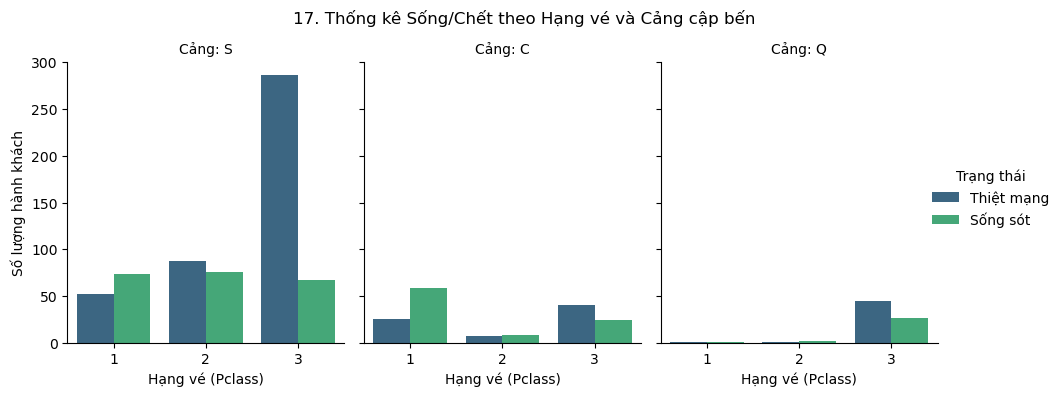

In [58]:
import warnings

# Tắt các cảnh báo FutureWarning để output sạch sẽ
warnings.simplefilter(action='ignore', category=FutureWarning)

# Đảm bảo tên cột là chữ thường
df.columns = df.columns.str.lower()

# Sử dụng catplot để tạo lưới biểu đồ (FacetGrid)
# col='embarked': Chia thành các cột dựa trên cảng (C, Q, S)
# x='pclass': Trục hoành là hạng vé
# hue='survived': Màu sắc phân biệt sống/chết
df['survived_str'] = df['survived'].map({0: 'Died', 1: 'Survived'})
g = sns.catplot(
    data=df, 
    x='pclass', 
    hue='survived_str', 
    col='embarked', 
    kind='count', 
    palette='viridis',
    height=4, 
    aspect=0.8
)

# Tinh chỉnh tiêu đề và nhãn
g.set_axis_labels("Hạng vé (Pclass)", "Số lượng hành khách")
g.set_titles("Cảng: {col_name}")
g._legend.set_title("Trạng thái")
new_labels = ['Thiệt mạng', 'Sống sót']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

plt.subplots_adjust(top=0.85)
g.fig.suptitle('17. Thống kê Sống/Chết theo Hạng vé và Cảng cập bến')
plt.show()